# 🎮 Gaming Behavior & Mental Health Analysis

Machine Learning Project  
Name: HKS


## Problem Statement

This project analyzes the relationship between gaming behavior and mental health using machine learning.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading Dataset


In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("GamingStudy_data.csv", encoding="latin1")

df.head()


Saving GamingStudy_data.csv to GamingStudy_data.csv


,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,...,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
0,1,42052.00437,0,0,0,0,1,0,0,Not difficult at all,...,USA,USA,Reddit,Singleplayer,Accept,1,23,5.0,USA,USA
1,2,42052.00680,1,2,2,2,0,1,0,Somewhat difficult,...,USA,USA,Reddit,Multiplayer - online - with strangers,Accept,8,16,33.0,USA,USA
2,3,42052.03860,0,2,2,0,0,3,1,Not difficult at all,...,Germany,Germany,Reddit,Singleplayer,Accept,8,17,31.0,DEU,DEU
3,4,42052.06804,0,0,0,0,0,0,0,Not difficult at all,...,USA,USA,Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11.0,USA,USA
4,5,42052.08948,2,1,2,2,2,3,2,Very difficult,...,USA,South Korea,Reddit,Multiplayer - online - with strangers,Accept,14,14,13.0,KOR,USA


In [4]:
df.shape

(13464, 55)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13464 entries, 0 to 13463
Data columns (total 55 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   S. No.           13464 non-null  int64  
 1   Timestamp        13464 non-null  float64
 2   GAD1             13464 non-null  int64  
 3   GAD2             13464 non-null  int64  
 4   GAD3             13464 non-null  int64  
 5   GAD4             13464 non-null  int64  
 6   GAD5             13464 non-null  int64  
 7   GAD6             13464 non-null  int64  
 8   GAD7             13464 non-null  int64  
 9   GADE             12815 non-null  object 
 10  SWL1             13464 non-null  int64  
 11  SWL2             13464 non-null  int64  
 12  SWL3             13464 non-null  int64  
 13  SWL4             13464 non-null  int64  
 14  SWL5             13464 non-null  int64  
 15  Game             13464 non-null  object 
 16  Platform         13464 non-null  object 
 17  Hours       

## Handling Missing Values


In [6]:
df = df.fillna(df.mean(numeric_only=True))


## Selecting Numeric Data


In [7]:
num_df = df.select_dtypes(include=np.number)

num_df.head()


,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,SWL1,...,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Age,GAD_T,SWL_T,SPIN_T
0,1,42052.00437,0,0,0,0,1,0,0,3,...,0.0,1.0,0.0,1.0,0.0,1.0,25,1,23,5.0
1,2,42052.00680,1,2,2,2,0,1,0,3,...,1.0,3.0,3.0,1.0,2.0,1.0,41,8,16,33.0
2,3,42052.03860,0,2,2,0,0,3,1,2,...,0.0,2.0,4.0,4.0,2.0,4.0,32,8,17,31.0
3,4,42052.06804,0,0,0,0,0,0,0,2,...,0.0,0.0,1.0,0.0,0.0,2.0,28,0,17,11.0
4,5,42052.08948,2,1,2,2,2,3,2,2,...,0.0,0.0,0.0,3.0,0.0,1.0,19,14,14,13.0


## Creating Mental Health Score


In [8]:
df['Mental_Score'] = num_df.mean(axis=1)


## Creating Risk Level


In [9]:
median_score = df['Mental_Score'].median()

df['Risk_Level'] = df['Mental_Score'].apply(
    lambda x: "High" if x >= median_score else "Low"
)


## Preparing Model Data


In [10]:
X = num_df
y = df['Risk_Level']


## Train-Test Split


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


## Training Decision Tree


In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5)

## Prediction

In [13]:
y_pred = model.predict(X_test)


## Model Evaluation


In [14]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9987623762376238


## Score Distribution


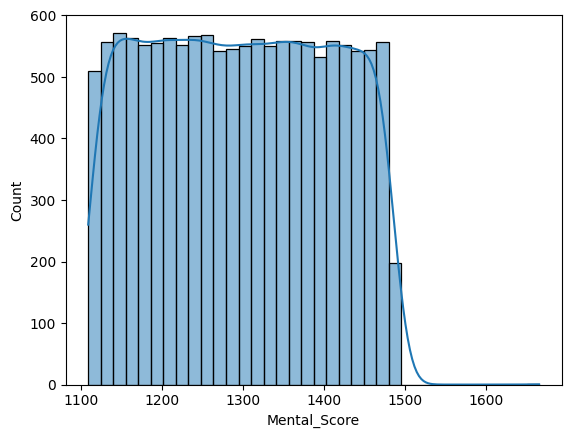

In [15]:
sns.histplot(df['Mental_Score'], kde=True)
plt.show()


## Important Factors Affecting Risk


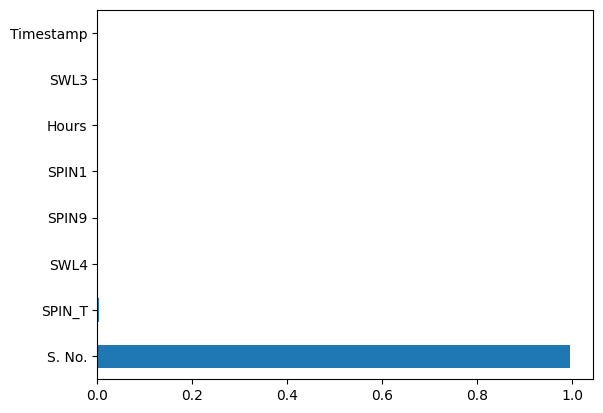

In [16]:
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

feat_imp.nlargest(8).plot(kind='barh')
plt.show()


## Confusion Matrix


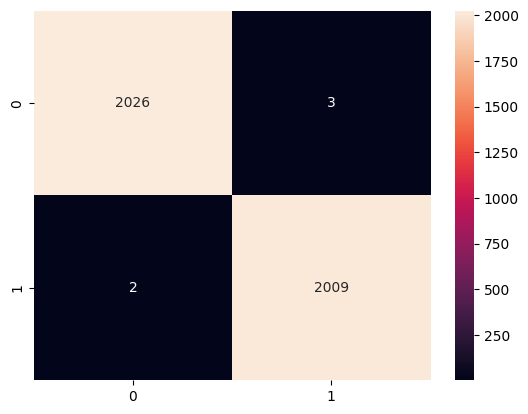

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()


## Recommendation System


In [18]:
def advice(level):
    if level == "High":
        return "Reduce gaming time and improve sleep."
    else:
        return "Healthy gaming habits!"

print("Example Advice:")
print(advice("High"))


Example Advice:
Reduce gaming time and improve sleep.


## Result

The model identifies patterns in gaming and mental health data.


## Conclusion

Machine learning helps analyze behavioral and mental health trends related to gaming.
